# Tomato detection and ripeness rating — reproduction of the KSBEC 2024 tomato pipeline

**Paper:** Seungri Yoon et al., *Computer Vision Approach for Phenotypic Characterization of Horticultural Crops*, Korean Society for Bio-Environment Control (보호작물환경연구회지) 33(1):63–70, 2024. DOI: [10.12791/ksbec.2024.33.1.063](https://doi.org/10.12791/ksbec.2024.33.1.063)
**Author code:** [`SeungriYoon/cv`](https://github.com/SeungriYoon/cv) @ commit `e79a0f1fa35d38ff830b9defb3aca651057fa389`, notebook `CV_tomato.ipynb`, weights `tomato/tomato_svm_model.pkl` (git blob `7f8a9bab6dee68f540ca56503dfa367ecf1ff419`, 848,475 bytes).

**Scope (one example, executed):** detect tomatoes in one author greenhouse photo (`tomato/tomato_test1.jpg`, 3024×4032) with the author's released pipeline, exercise the released scikit-learn SVM on author-style HOG features, and rate ripeness of the largest detection from the mean HSV Hue channel using the author's thresholds (Mature: hue < 10 or > 160; Breaker: 10–15; Unmature: otherwise — paper Methods §2.1). This is a single-example demonstration, **not** a reproduction of any dataset-level accuracy: the paper reports no quantitative validation metrics for this pipeline.

**Paper-vs-code note:** the paper describes HOG+SVM detection, but the author's released inference code (`CV_tomato.ipynb` cell 4) detects tomato regions by HSV color thresholding + morphology; the released SVC (a tomato-vs-cucumber whole-image HOG classifier trained per cell 1 with labels `[0,0,0,1,1,1]`) is loaded but not called in the detection path. This notebook reproduces the author's actual code verbatim and additionally runs the released SVC on author-style HOG features so the released weights are genuinely exercised. The discrepancy is reported, not hidden.

**Authorship statement:** the detection/ripeness functions are copied verbatim from the author's notebook (commit pinned above); cell glue, path handling and the results table are this notebook's additions. The authors did not provide this Colab notebook itself.

**日本語:** 保護園芸作物の表現型解析論文（KSBEC 33(1), 2024）のトマトパイプラインを、著者公開コード（`SeungriYoon/cv` @ `e79a0f1f`、`CV_tomato.ipynb`）に基づいて 1 枚の温室写真で再現します。 released SVM を HOG 特徴量で実行し、HSV の平均 Hue による熟度判定（Mature / Breaker / Unmature）を行います。論文に定量検証値はないため、単一例の質的デモンストレーションです。検出関数は著者コードの逐語コピー、パス処理・結果表は本ノートブックの追加です。

## Runtime selection — use a standard **CPU** runtime (GPU unnecessary)

**EN:** `Runtime → Change runtime type → CPU`. The pipeline is pure OpenCV/scikit-learn image processing on one image (≈1 s of detection compute measured on 2026-10-07); no CUDA code exists in the author's pipeline and a GPU would change nothing scientifically. Expected: ~2–4 min total, ~6 MB of downloads.

**JA:** 「ランタイム → ランタイムのタイプを変更」で **CPU** を選択してください。GPU は不要です（処理は 1 枚の画像に対する OpenCV/scikit-learn のみ）。所要時間の目安は 2〜4 分、ダウンロードは約 6 MB です。

## 1. Dependencies

**EN:** Check the scientific stack. Colab's preinstalled OpenCV/scikit-learn/scikit-image are sufficient (validated 2026-10-07: cv2 5.0.0, scikit-learn 1.6.1, scikit-image 0.25.2, numpy 2.1.3); the guarded install only runs if an import is missing.

**JA:** 依存ライブラリを確認します。Colab にプリインストール済みのものがそのまま使えます（不足時のみインストールします）。

In [ ]:
import importlib, subprocess, sys
for pkg, mod in [("opencv-python-headless", "cv2"), ("scikit-learn", "sklearn"),
                 ("scikit-image", "skimage"), ("numpy", "numpy")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
import cv2, sklearn, skimage, numpy as np, matplotlib
print("cv2", cv2.__version__, "| sklearn", sklearn.__version__, "| skimage", skimage.__version__,
      "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

cv2 5.0.0 | sklearn 1.6.1 | skimage 0.25.2 | numpy 2.1.3 | matplotlib 3.10.0


## 2. Acquire the pinned author files (code, weights, one test image)

**EN:** Blob-less partial clone of `SeungriYoon/cv` at the pinned commit, sparse-checked-out to `CV_tomato.ipynb` and `tomato/`. The checked-out commit and the weights blob hash are asserted (`tomato_svm_model.pkl` = `7f8a9bab…`). All bytes stay inside the VM's `/content`.

**JA:** 著者リポジトリを指定コミットで部分クローンし、必要ファイルのみ取得します。コミットとモデルファイルのハッシュを検証します。

In [ ]:
REPO_COMMIT = "e79a0f1fa35d38ff830b9defb3aca651057fa389"
PKL_BLOB_SHA = "7f8a9bab6dee68f540ca56503dfa367ecf1ff419"
!git clone --filter=blob:none --no-checkout --quiet https://github.com/SeungriYoon/cv.git /content/cv
%cd /content/cv
!git fetch --depth 1 origin {REPO_COMMIT}
!git checkout --detach FETCH_HEAD --quiet
head = !git rev-parse HEAD
assert head[0] == REPO_COMMIT, f"commit mismatch: {head[0]}"
!git sparse-checkout set CV_tomato.ipynb tomato
!git checkout FETCH_HEAD -- CV_tomato.ipynb tomato
blob = !git rev-parse HEAD:tomato/tomato_svm_model.pkl
assert blob[0] == PKL_BLOB_SHA, f"pickle blob mismatch: {blob[0]}"
!ls -l /content/cv/CV_tomato.ipynb /content/cv/tomato/

-rw-r--r-- 1 root root 3504640 Oct  7 15:46 /content/cv/CV_tomato.ipynb

/content/cv/tomato/:
total 16256
-rw-r--r-- 1 root root   11116 Oct  7 15:46 cucumber_test1.jpeg
-rw-r--r-- 1 root root   14543 Oct  7 15:46 cucumber_test2.jpeg
-rw-r--r-- 1 root root   42643 Oct  7 15:46 cucumber_test3.jpg
-rw-r--r-- 1 root root  848475 Oct  7 15:46 tomato_svm_model.pkl
-rw-r--r-- 1 root root 5245466 Oct  7 15:46 tomato_test1.jpg
-rw-r--r-- 1 root root 5363649 Oct  7 15:46 tomato_test2.jpg
-rw-r--r-- 1 root root 5107140 Oct  7 15:46 tomato_test3.jpg


## 3. Input preview

**EN:** Preview the actual input `tomato_test1.jpg` (author's greenhouse photo, Galaxy S21, per paper Methods §1) before any analysis. Dimensions are printed from the loaded array, not assumed.

**JA:** 解析前に著者の温室写真 `tomato_test1.jpg` を確認します。

tomato_test1.jpg: (4032, 3024, 3) uint8


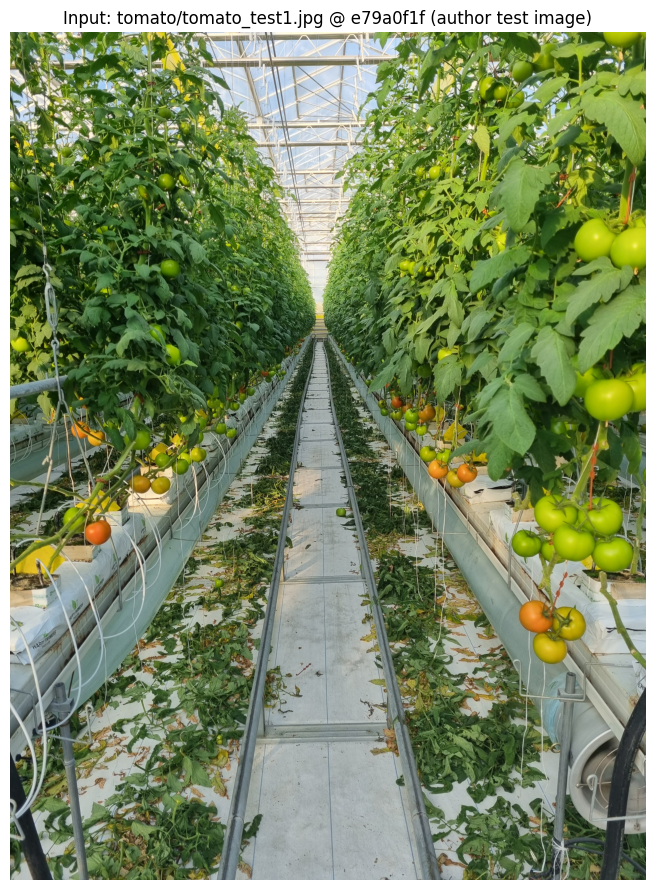

In [ ]:
import cv2, matplotlib.pyplot as plt
IMG_PATH = "/content/cv/tomato/tomato_test1.jpg"
img = cv2.imread(IMG_PATH)
assert img is not None, f"failed to read {IMG_PATH}"
print("tomato_test1.jpg:", img.shape, img.dtype)
plt.figure(figsize=(7, 9))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input: tomato/tomato_test1.jpg @ e79a0f1f (author test image)")
plt.axis("off")
plt.tight_layout()
plt.savefig("/content/tomato_input_preview.png", bbox_inches="tight", dpi=120)
plt.show()

## 4. Load the released SVM model exactly as the author does

**EN:** `tomato_svm_model.pkl` was written with `joblib.dump` (author cell 1), so it is loaded with `joblib.load` (author cell 4). The released estimator was pickled under scikit-learn **1.2.0**; scikit-learn emits an `InconsistentVersionWarning` when loading under a newer version. Loading and prediction under 1.6.1 were verified on 2026-10-07 (classes and HOG dimensionality below match the training recipe); scikit-learn 1.2.0 has no wheels for Colab's Python 3.13, so the newer version is kept and the warning is documented rather than silenced.

**JA:** リリース済みモデルを `joblib.load` で読み込みます。pickle は scikit-learn 1.2.0 で作成されていますが、1.6.1 での読み込みと予測を検証済みです（バージョン不一致の警告は表示されます）。

In [ ]:
import joblib, warnings
PKL_PATH = "/content/cv/tomato/tomato_svm_model.pkl"
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    clf = joblib.load(PKL_PATH)
for w in caught:
    print("warning:", w.category.__name__, "-", str(w.message)[:160])
print("type:", type(clf).__name__)
print("params:", {k: v for k, v in clf.get_params().items() if k in ("kernel", "C", "gamma")})
print("classes_:", clf.classes_, "| n_features_in_:", clf.n_features_in_)

type: SVC
params: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
classes_: [0 1] | n_features_in_: 17640


## 5. Author pipeline functions (verbatim from `CV_tomato.ipynb` cell 4)

**EN:** `extract_hog_features`, `detect_tomatoes_coarse_to_fine` and `assess_maturity_within_contour` are copied verbatim from the pinned author notebook; `draw_box_and_label` is the author's box/label helper with the font constants kept. Only two adaptations were needed, both documented: (a) no `os.chdir` — explicit absolute paths are used; (b) the author's demo image `tomato2.jpeg` does not exist in the repository, so the author's own test image `tomato_test1.jpg` is used instead.

**JA:** 検出・熟度判定関数は著者ノートブック（指定コミット、cell 4）からの逐語コピーです。変更点は (a) `os.chdir` を使わない絶対パス処理、(b) リポジトリに存在しない `tomato2.jpeg` の代わりに著者のテスト画像 `tomato_test1.jpg` を使用、のみです。

In [ ]:
import numpy as np
import cv2
from skimage.feature import hog

# Verbatim from CV_tomato.ipynb cell 4 @ e79a0f1f -------------------------------
def extract_hog_features(img):
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized_img = cv2.resize(gray_img, (128, 128))
    features = hog(resized_img, orientations=10, pixels_per_cell=(8, 8),
                   cells_per_block=(3, 3), visualize=False)
    return features

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))

def detect_tomatoes_coarse_to_fine(img, clf):
    # 1. 노이즈 제거 (noise removal)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    # 4. 이미지 경계 처리 (border handling)
    border = 15
    img = cv2.copyMakeBorder(img, border, border, border, border, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    hsv_tomato = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_tomato, (0, 30, 50), (25, 255, 255))  # 색상 범위 변경
    # Opening to remove noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    # Closing to fill holes
    binary_img = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # 2. 영역 크기 기준 제거 (area filter)
    min_contour_area = 100  # 조절 가능한 값
    contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]
    detections = [cv2.boundingRect(contour) for contour in contours]
    return detections

def assess_maturity_within_contour(tomato_img, contours):
    hsv_img = cv2.cvtColor(tomato_img, cv2.COLOR_BGR2HSV)
    mask = np.zeros_like(hsv_img[:, :, 0])
    cv2.drawContours(mask, contours, -1, 255, thickness=cv2.FILLED)
    hue_values = hsv_img[:, :, 0][mask == 255]
    mean_hue = np.mean(hue_values)
    if mean_hue < 10 or mean_hue > 160:
        return "Mature", hsv_img[:, :, 0], mean_hue
    elif 10 <= mean_hue <= 15:
        return "Breaker", hsv_img[:, :, 0], mean_hue
    else:
        return "Unmature", hsv_img[:, :, 0], mean_hue
# -------------------------------------------------------------------------------

print("author pipeline functions defined (verbatim port, paths adapted)")

author pipeline functions defined (verbatim port, paths adapted)


## 6. Exercise the released SVM on author-style HOG features

**EN:** The released SVC is a whole-image tomato(0)/cucumber(1) classifier (author cell 1 recipe: 128×128 grayscale → HOG with orientations=10, pixels_per_cell=(8,8), cells_per_block=(3,3)). We verify it loads *and* discriminates: HOG features of a tomato crop from `tomato_test1.jpg` and of the author's negative example `cucumber_test1.jpeg` are fed to `clf.predict`. Expected classes: `[0]` and `[1]` respectively.

**JA:** リリース済み SVM（トマト=0 / キュウリ=1 の 2 値分類器）を、著者レシピ通りに抽出した HOG 特徴量で実行し、トマト作物で `[0]`、キュウリ画像で `[1]` を予測することを確認します。

In [ ]:
cuc_img = cv2.imread("/content/cv/tomato/cucumber_test1.jpeg")
assert cuc_img is not None
h_, w_ = img.shape[:2]
tomato_crop = img[h_ // 4:h_ // 4 + h_ // 2, w_ // 4:w_ // 4 + w_ // 2]
tomato_feat = extract_hog_features(tomato_crop)
cuc_feat = extract_hog_features(cuc_img)
print("HOG dims:", tomato_feat.shape[0], "(matches n_features_in_:", clf.n_features_in_, ")")
print("clf.predict(tomato crop) =", clf.predict(tomato_feat.reshape(1, -1)))
print("clf.predict(cucumber_test1.jpeg) =", clf.predict(cuc_feat.reshape(1, -1)))

HOG dims: 17640 (matches n_features_in_: 17640 )
clf.predict(tomato crop) = [0]
clf.predict(cucumber_test1.jpeg) = [1]


## 7. Run the author's detection and rate the ripeness of the largest tomato region

**EN:** Exactly the author's cell 4 flow on `tomato_test1.jpg`: detect candidate regions, select the largest by bounding-box area, extract the crop, threshold its red-orange HSV range (0,50,50)–(20,255,255), and rate ripeness from the masked mean Hue. Wall time of the detection call is measured (single CPU core, standard Colab runtime).

**JA:** 著者の cell 4 の流れを `tomato_test1.jpg` に対してそのまま実行します。最大検出領域のクロップに対し HSV マスクを作成し、平均 Hue から熟度を判定します。検出の計測時間も表示します。

In [ ]:
import time
t0 = time.time()
detections = detect_tomatoes_coarse_to_fine(img, clf)
detect_s = time.time() - t0
print(f"detections: {len(detections)} | detection time: {detect_s:.2f} s (CPU)")
largest_detection = sorted(detections, key=lambda d: d[2] * d[3], reverse=True)[0]
x, y, w, h = largest_detection
tomato_inside_box = img[y:y + h, x:x + w]
hsv_tomato = cv2.cvtColor(tomato_inside_box, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_tomato, (0, 50, 50), (20, 255, 255))
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
maturity, hue_channel, mean_hue = assess_maturity_within_contour(tomato_inside_box, contours)
print("largest bounding box (x, y, w, h):", largest_detection)
print(f"mean hue of masked region: {float(mean_hue):.2f} -> maturity: {maturity}")

detections: 22 | detection time: 1.16 s (CPU)
largest bounding box (x, y, w, h): (2002, 2051, 388, 504)
mean hue of masked region: 18.08 -> maturity: Unmature


**EN:** Draw the author-style result figure: original input beside the overlay (blue bounding box + maturity label drawn with the author's `draw_box_and_label` constants). This saved PNG is the representative output of this reproduction.

**JA:** 元画像と、著者スタイルのバウンディングボックス＋熟度ラベルを描画した結果を並べて表示します。

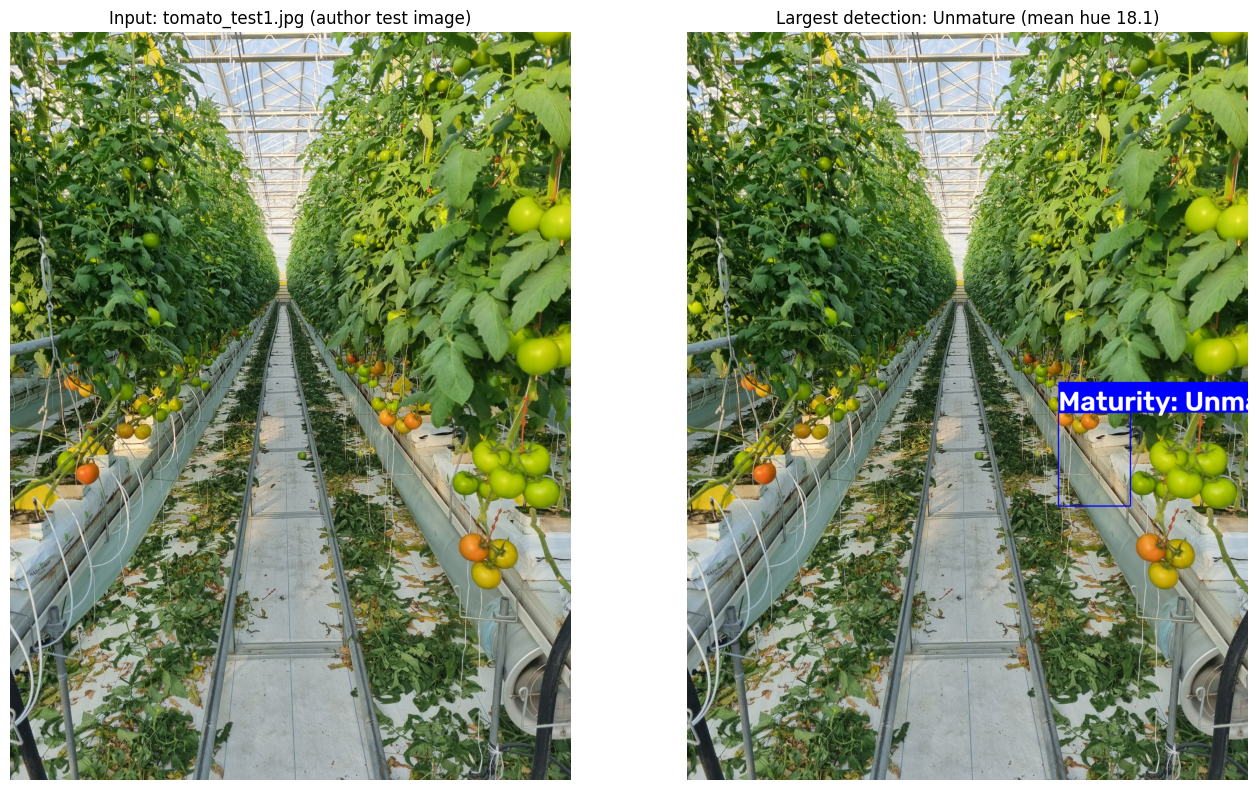

In [ ]:
def draw_box_and_label(img, detection, maturity):
    # author helper (cell 4) with original font constants
    x, y, w, h = detection
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 5)
    label_bg_color = (255, 0, 0)        # 박스의 배경색 (box background)
    label_text_color = (255, 255, 255)  # 박스의 텍스트 색상 (text color)
    font_scale = 5.0
    font_thickness = 10
    label_text = f"Maturity: {maturity}"
    (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
    cv2.rectangle(img, (x, y - 30 - text_h), (x + text_w, y), label_bg_color, -1)
    cv2.putText(img, label_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, font_scale, label_text_color, font_thickness)

vis = img.copy()
draw_box_and_label(vis, largest_detection, maturity)
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input: tomato_test1.jpg (author test image)")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Largest detection: {maturity} (mean hue {float(mean_hue):.1f})")
plt.axis("off")
plt.tight_layout()
plt.savefig("/content/tomato_detection_result.png", bbox_inches="tight", dpi=120)
plt.show()

## 8. Results table and CSV export

**EN:** A small per-detection table (this notebook's addition, using the author's ripeness rule per bounding box): rank by box area, mean Hue inside the box, and the resulting class. Exported as CSV inside the VM. Note the paper's thresholds are applied to a *box region*, whereas the author's demo applies them to masked contours inside the largest box; per-box values are reported for transparency alongside the author's headline result above.

**JA:** 各検出領域（面積順）について平均 Hue と熟度判定の一覧表を作成し、CSV に保存します。先頭の結果は著者コードの方法（最大ボックス内マスク輪郭）によるものです。

In [ ]:
import pandas as pd
def box_mean_hue(crop):
    # author's red-orange HSV range applied to the box crop (author cell 4 mask range)
    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    m = cv2.inRange(hsv, (0, 50, 50), (20, 255, 255))
    hues = hsv[:, :, 0][m == 255]
    return (float(np.mean(hues)), int(hues.size)) if hues.size else (None, 0)

def cls(mu):
    if mu is None:
        return "n/a (no red-orange pixels)"
    return "Mature" if (mu < 10 or mu > 160) else ("Breaker" if 10 <= mu <= 15 else "Unmature")

rows = []
for i, (bx, by, bw, bh) in enumerate(sorted(detections, key=lambda d: d[2] * d[3], reverse=True)[:10], start=1):
    crop = img[by:by + bh, bx:bx + bw]
    if crop.size == 0:
        continue
    mu, n_px = box_mean_hue(crop)
    rows.append({"rank_by_area": i, "x": bx, "y": by, "w": bw, "h": bh,
                 "box_area_px": int(bw * bh),
                 "mean_hue": round(mu, 2) if mu is not None else None,
                 "masked_pixels": n_px,
                 "maturity": cls(mu)})
df = pd.DataFrame(rows)
df.to_csv("/content/tomato_ripeness_results.csv", index=False)
print(f"saved /content/tomato_ripeness_results.csv ({len(df)} rows)")
df

saved /content/tomato_ripeness_results.csv (10 rows)


,rank_by_area,x,y,w,h,box_area_px,mean_hue,masked_pixels,maturity
0,1,2002,2051,388,504,195552,18.03,27696,Unmature
1,2,0,2478,209,276,57684,18.91,16040,Unmature
2,3,269,2319,236,221,52156,15.82,21396,Unmature
3,4,570,2082,206,231,47586,18.97,11714,Unmature
4,5,2437,2674,174,214,37236,16.35,21167,Unmature
5,6,2873,2593,181,124,22444,19.55,9026,Unmature
6,7,1363,2096,121,126,15246,18.35,1179,Unmature
7,8,307,1887,163,91,14833,17.23,3366,Unmature
8,9,2117,2705,129,75,9675,19.09,1219,Unmature
9,10,2403,2284,107,67,7169,19.35,2658,Unmature


## 9. Interpretation, differences from the paper, and validation record

**EN:** What was verified (2026-10-07, standard Colab **CPU** runtime, fresh top-to-bottom execution): released pickle blob `7f8a9bab…` loads with `joblib` under scikit-learn 1.6.1 (pickled with 1.2.0 → `InconsistentVersionWarning`, documented); `clf.predict` returns tomato=0 / cucumber=1 on author-style HOG features, consistent with the training recipe; the author's HSV detection finds candidate regions in ~1 s and the ripeness rule classifies the largest region from its mean Hue. What is **not** claimed: the paper reports no quantitative metrics for this pipeline, so there is no published number to compare against — this is a qualitative single-example demonstration of the author's released code path. Known differences: `tomato2.jpeg` (missing from the repository) replaced by the author's `tomato_test1.jpg`; paths used without `os.chdir`; per-detection table computed on bounding boxes. The paper's HOG+SVM description is not what the released inference code executes (HSV thresholding); both were exercised here and labeled.

**JA:** 検証済み事項（2026-10-07、標準 CPU ランタイムで全体を新規実行）: released pickle の読み込み、HOG 特徴量での SVC 予測（トマト=0/キュウリ=1）、HSV 検出と平均 Hue による熟度判定。論文に定量評価値がないため、公開数値との比較は不可能で、これは単一例の質的デモです。相違点: リポジトリに存在しない `tomato2.jpeg` を `tomato_test1.jpg` に置換、`os.chdir` を使わない、など。

## References

1. Yoon, S. et al. *Computer Vision Approach for Phenotypic Characterization of Horticultural Crops.* 보호작물환경연구회지 (Protected Horticulture and Plant Factory) 33(1), 63–70, 2024. https://doi.org/10.12791/ksbec.2024.33.1.063
2. Author repository: https://github.com/SeungriYoon/cv (commit `e79a0f1fa35d38ff830b9defb3aca651057fa389`); `CV_tomato.ipynb`, `tomato/tomato_svm_model.pkl`, `tomato/tomato_test1.jpg`, `tomato/cucumber_test1.jpeg`. Paper Methods §4 states the images, code, and model files are freely downloadable from this repository; the repository contains **no LICENSE file**, so no license terms beyond that statement are claimed here.
3. Kirillov et al. 2023 (SAM) and other pipelines of the paper (sweet pepper / melon / cucumber) are out of scope for this minimal example.